# Entrega 1 — Análise Descritiva dos Dados


**Objetivo desta entrega (conforme o documento do projeto):** realizar uma análise descritiva completa das 6 contas-chave já validadas — Receita, EBITDA, Lucro Líquido, Geração de Caixa, Distribuição a Acionistas e Saldo Final — calculando medidas de posição (média, mediana, moda) e de dispersão (variância, desvio padrão), além de histogramas e boxplots, para entender o comportamento geral, a distribuição, a variabilidade e possíveis valores atípicos **antes** da análise de regressão (Entrega 2).

**Como usar:** rode as células em ordem. No final (última célula) dá pra baixar todas as tabelas geradas em um `.zip` para montar o relatório Word/PDF desta entrega.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Passo 1 — Upload do arquivo CSV

In [ ]:
from google.colab import files
uploaded = files.upload()
nome_arquivo = list(uploaded.keys())[0]

Saving Demonstrativo Fecap v3.csv to Demonstrativo Fecap v3.csv


## Passo 2 — Carregar e tratar os dados

O CSV está em UTF-8, separado por `;`, com números no formato brasileiro (ponto de milhar, vírgula decimal). As 4 colunas são: Ano, Cenário, Conta, Valor.

In [ ]:
df = pd.read_csv(nome_arquivo, encoding='utf-8', sep=';', header=None,
                  names=['Ano', 'Cenario', 'Conta', 'Valor'])
df = df.dropna(subset=['Conta'])

def br_para_float(x):
    x = x.replace('.', '').replace(',', '.')
    return float(x)

df['Valor_num'] = df['Valor'].apply(br_para_float)
df['AnoNum'] = df['Ano'].str.extract(r'(\d+)').astype(int)

print(df.shape)
df.head()

(958800, 6)


,Ano,Cenario,Conta,Valor,Valor_num,AnoNum
1,Ano 1,Total Cen_00001,BAL - Total do Ativo,"10.631.127.075,2579",1.063113e+10,1
2,Ano 1,Total Cen_00001,BAL - Ativo Circulante,"1.795.720.872,17537",1.795721e+09,1
3,Ano 1,Total Cen_00001,BAL - Disponível,"1.205.264.965,51818",1.205265e+09,1
4,Ano 1,Total Cen_00001,BAL - Contas a Receber - SWAP,"95.680.421,9232409",9.568042e+07,1
5,Ano 1,Total Cen_00001,BAL - Contas a Receber - Partes Relacionadas,"584.661,46688296",5.846615e+05,1


## Passo 3 — Selecionar as 6 contas-chave

Reorganizamos a base para uma linha por cenário/ano, e mantemos só as 6 contas que serão o foco desta entrega.

In [ ]:
contas_chave = ['DRE - Receita', 'DRE - Resultado Líquido', 'DRE - EBITDA',
                'FLU - Geração de Caixa', 'FLU - Distribuição para Acionista', 'FLU - Saldo Final']

pivot = df.pivot_table(index=['AnoNum', 'Cenario'], columns='Conta', values='Valor_num')
pivot = pivot[contas_chave]
pivot.head()

Conta                   DRE - Receita  DRE - Resultado Líquido  DRE - EBITDA  \
AnoNum Cenario                                                                 
1      Total Cen_00001   6.722729e+09             2.443243e+09  5.188381e+09   
       Total Cen_00002   6.703608e+09             2.436562e+09  5.172388e+09   
       Total Cen_00003   6.676361e+09             2.434790e+09  5.149189e+09   
       Total Cen_00004   6.672623e+09             2.435385e+09  5.146146e+09   
       Total Cen_00005   6.660653e+09             2.416009e+09  5.136879e+09   

Conta                   FLU - Geração de Caixa  \
AnoNum Cenario                                   
1      Total Cen_00001            4.306498e+08   
       Total Cen_00002            4.243157e+08   
       Total Cen_00003            4.211763e+08   
       Total Cen_00004            4.216127e+08   
       Total Cen_00005            4.052842e+08   

Conta                   FLU - Distribuição para Acionista  FLU - Saldo Final  
AnoNum Cenario                                                                
1      Total Cen_00001                      -1.532408e+09       1.205265e+09  
       Total Cen_00002                      -1.532408e+09       1.198931e+09  
       Total Cen_00003                      -1.532408e+09       1.195792e+09  
       Total Cen_00004                      -1.532408e+09       1.196228e+09  
       Total Cen_00005                      -1.532408e+09       1.179899e+09

## Passo 4 — Qualidade rápida dos dados

Antes de qualquer estatística, confirmamos que não há valores ausentes ou duplicados nas 6 contas-chave, e conferimos o volume de dados (1.200 cenários × 12 anos).

**O que esperar:** zero valores ausentes e zero duplicados — como os dados vêm de uma simulação estruturada, isso é esperado. Se aparecer algo diferente de zero, vale investigar antes de seguir.

In [ ]:
print('Formato da base original:', df.shape)
print()

print('Valores ausentes por conta:')
print(pivot.isna().sum())
print()

duplicados = df.duplicated(subset=['AnoNum', 'Cenario', 'Conta']).sum()
print('Registros duplicados na base original:', duplicados)
print()

print('Quantidade de anos:', df['AnoNum'].nunique())
print('Quantidade de cenários por ano:')
print(df.groupby('AnoNum')['Cenario'].nunique())
print()

print('Tipos de dado:')
print(pivot.dtypes)

Formato da base original: (958800, 6)

Valores ausentes por conta:
Conta
DRE - Receita                        0
DRE - Resultado Líquido              0
DRE - EBITDA                         0
FLU - Geração de Caixa               0
FLU - Distribuição para Acionista    0
FLU - Saldo Final                    0
dtype: int64

Registros duplicados na base original: 0

Quantidade de anos: 12
Quantidade de cenários por ano:
AnoNum
1     1200
2     1200
3     1200
4     1200
5     1200
6     1200
7     1200
8     1200
9     1200
10    1200
11    1200
12    1200
Name: Cenario, dtype: int64

Tipos de dado:
Conta
DRE - Receita                        float64
DRE - Resultado Líquido              float64
DRE - EBITDA                         float64
FLU - Geração de Caixa               float64
FLU - Distribuição para Acionista    float64
FLU - Saldo Final                    float64
dtype: object


## Passo 5 — Medidas de posição: média, mediana e moda

**Média** e **mediana** são diretas. A **moda** exige um cuidado: como os valores são financeiros contínuos (cada cenário simulado tende a gerar um número praticamente único), a moda "literal" não é informativa — não existem dois cenários com exatamente o mesmo valor de Receita, por exemplo. Por isso, calculamos uma **moda aproximada**: dividimos os valores em 50 faixas (bins) e identificamos a faixa com maior concentração de cenários — o "intervalo mais frequente" da distribuição.

**O que esperar:** para cada conta, uma linha com os três valores. Se média e mediana estiverem próximas, a distribuição é relativamente simétrica; se estiverem bem distantes, há assimetria (cauda longa para um dos lados).

In [ ]:
def moda_aproximada(serie, n_bins=50):
    contagem, bordas = np.histogram(serie.dropna(), bins=n_bins)
    idx_max = contagem.argmax()
    return (bordas[idx_max] + bordas[idx_max + 1]) / 2

medidas_posicao = pd.DataFrame({
    'media': pivot.mean(),
    'mediana': pivot.median(),
    'moda_aproximada': pivot.apply(moda_aproximada),
})
medidas_posicao

,media,mediana,moda_aproximada
Conta,,,
DRE - Receita,7.913424e+09,7.336984e+09,6.193481e+09
DRE - Resultado Líquido,3.356646e+09,2.978877e+09,2.377391e+09
DRE - EBITDA,6.504509e+09,5.937502e+09,5.169759e+09
FLU - Geração de Caixa,-2.792000e+07,1.631435e+08,5.090072e+08
FLU - Distribuição para Acionista,-3.434814e+09,-2.875356e+09,-2.536726e+09
FLU - Saldo Final,1.135680e+09,1.088178e+09,2.376499e+08


## Passo 6 — Medidas de dispersão: variância e desvio padrão

Complementam a média mostrando o quão espalhados os 14.400 valores (1.200 cenários × 12 anos) estão em torno dela.

**O que esperar:** contas com desvio padrão muito maior que a média (relativo) indicam alta variabilidade — coerente com o que já vimos: Geração de Caixa costuma ser a conta mais dispersa das seis.

In [ ]:
medidas_dispersao = pd.DataFrame({
    'variancia': pivot.var(),
    'desvio_padrao': pivot.std(),
    'coeficiente_variacao': pivot.std() / pivot.mean()
})

medidas_dispersao

,variancia,desvio_padrao,coeficiente_variacao
Conta,,,
DRE - Receita,2.783660e+18,1.668430e+09,0.210835
DRE - Resultado Líquido,1.776101e+18,1.332705e+09,0.397035
DRE - EBITDA,3.293554e+18,1.814815e+09,0.279009
FLU - Geração de Caixa,8.388363e+17,9.158801e+08,-32.803724
FLU - Distribuição para Acionista,4.415384e+18,2.101281e+09,-0.611760
FLU - Saldo Final,7.257806e+17,8.519276e+08,0.750148


## Passo 7 — As mesmas medidas, agora por ano

A visão acima junta todos os 12 anos. Aqui repetimos média, mediana e desvio padrão **separadamente para cada ano**, o que é mais útil para o relatório porque mostra a evolução ao longo do tempo, não só um retrato único.

In [ ]:
medidas_por_ano = pivot.groupby('AnoNum').agg(['mean', 'median', 'std'])
medidas_por_ano

Conta  DRE - Receita                             DRE - Resultado Líquido  \
                mean        median           std                    mean   
AnoNum                                                                     
1       6.679148e+09  6.668624e+09  3.511449e+07            2.416060e+09   
2       6.089661e+09  6.085912e+09  4.204730e+07            1.967242e+09   
3       6.254778e+09  6.256076e+09  5.550463e+07            2.113482e+09   
4       6.514278e+09  6.515036e+09  7.272980e+07            2.302376e+09   
5       6.845595e+09  6.845117e+09  9.178567e+07            2.635126e+09   
6       7.248546e+09  7.245086e+09  1.137496e+08            2.950871e+09   
7       7.673514e+09  7.668943e+09  1.396257e+08            3.141984e+09   
8       8.165980e+09  8.156250e+09  1.699996e+08            3.397817e+09   
9       8.633368e+09  8.618774e+09  2.037171e+08            3.668072e+09   
10      9.170849e+09  9.151528e+09  2.422824e+08            4.132669e+09   
11      9.722985e+09  9.697609e+09  2.854204e+08            4.654034e+09   
12      1.196239e+10  1.192989e+10  3.303170e+08            6.900022e+09   

Conta                               DRE - EBITDA                              \
              median           std          mean        median           std   
AnoNum                                                                         
1       2.428373e+09  4.539599e+07  5.152102e+09  5.142975e+09  3.047264e+07   
2       1.985126e+09  5.731007e+07  4.615494e+09  4.613350e+09  3.564460e+07   
3       2.129344e+09  5.109006e+07  4.896584e+09  4.897521e+09  4.894614e+07   
4       2.325256e+09  6.960721e+07  5.169079e+09  5.173049e+09  6.450899e+07   
5       2.652607e+09  6.791527e+07  5.472535e+09  5.474861e+09  8.107179e+07   
6       2.961136e+09  7.095230e+07  5.836869e+09  5.834809e+09  9.919775e+07   
7       3.152495e+09  8.494313e+07  6.221629e+09  6.221455e+09  1.208362e+08   
8       3.410298e+09  1.024203e+08  6.650721e+09  6.649395e+09  1.456404e+08   
9       3.687571e+09  1.302067e+08  7.061535e+09  7.057399e+09  1.736891e+08   
10      4.150731e+09  1.591435e+08  7.543996e+09  7.535968e+09  2.062638e+08   
11      4.667594e+09  1.889142e+08  8.007699e+09  7.995440e+09  2.423951e+08   
12      6.912336e+09  2.252268e+08  1.142586e+10  1.140949e+10  2.816164e+08   

Conta  FLU - Geração de Caixa                              \
                         mean        median           std   
AnoNum                                                      
1                3.432745e+08  4.158085e+08  1.826196e+08   
2               -2.403491e+08 -1.942555e+08  1.172573e+08   
3                7.131920e+08  7.343328e+08  6.208597e+07   
4               -6.243099e+08 -6.327643e+08  6.368626e+07   
5               -7.098024e+08 -8.030491e+08  2.248247e+08   
6               -2.179193e+07 -3.032143e+07  4.210266e+07   
7                1.466313e+08  1.610914e+08  8.010193e+07   
8                8.803332e+08  9.233143e+08  1.669388e+08   
9                4.509495e+08  4.937548e+08  1.729633e+08   
10               2.849250e+08  2.885078e+08  1.364489e+08   
11               7.932197e+08  7.953243e+08  1.693960e+08   
12              -2.351312e+09 -2.663794e+09  1.019658e+09   

Conta  FLU - Distribuição para Acionista                              \
                                    mean        median           std   
AnoNum                                                                 
1                          -1.532408e+09 -1.532408e+09  0.000000e+00   
2                          -2.553746e+09 -2.553746e+09  0.000000e+00   
3                          -2.069738e+09 -2.069738e+09  0.000000e+00   
4                          -2.207929e+09 -2.227234e+09  6.029506e+07   
5                          -2.460296e+09 -2.460296e+09  0.000000e+00   
6                          -2.760569e+09 -2.760569e+09  0.000000e+00   
7                          -2.990142e+09 -2.990142e+09  0.000000e+00   
8                     

## Passo 8 — Histogramas

Mostram a forma da distribuição de cada conta — se é simétrica, se tem cauda longa para algum lado, se há mais de um "pico" (bimodalidade). Aqui usamos o **Ano 12** como referência, por ser o ano de maior interesse identificado na exploração anterior — troquem a variável `ano_histograma` para ver outro ano.

**O que esperar:** histogramas com forma de sino são "bem-comportados". Formas assimétricas, com cauda esticada para a esquerda ou direita, ou com dois picos separados, são sinais que merecem explicação no relatório (não são erro, mas precisam ser interpretados).

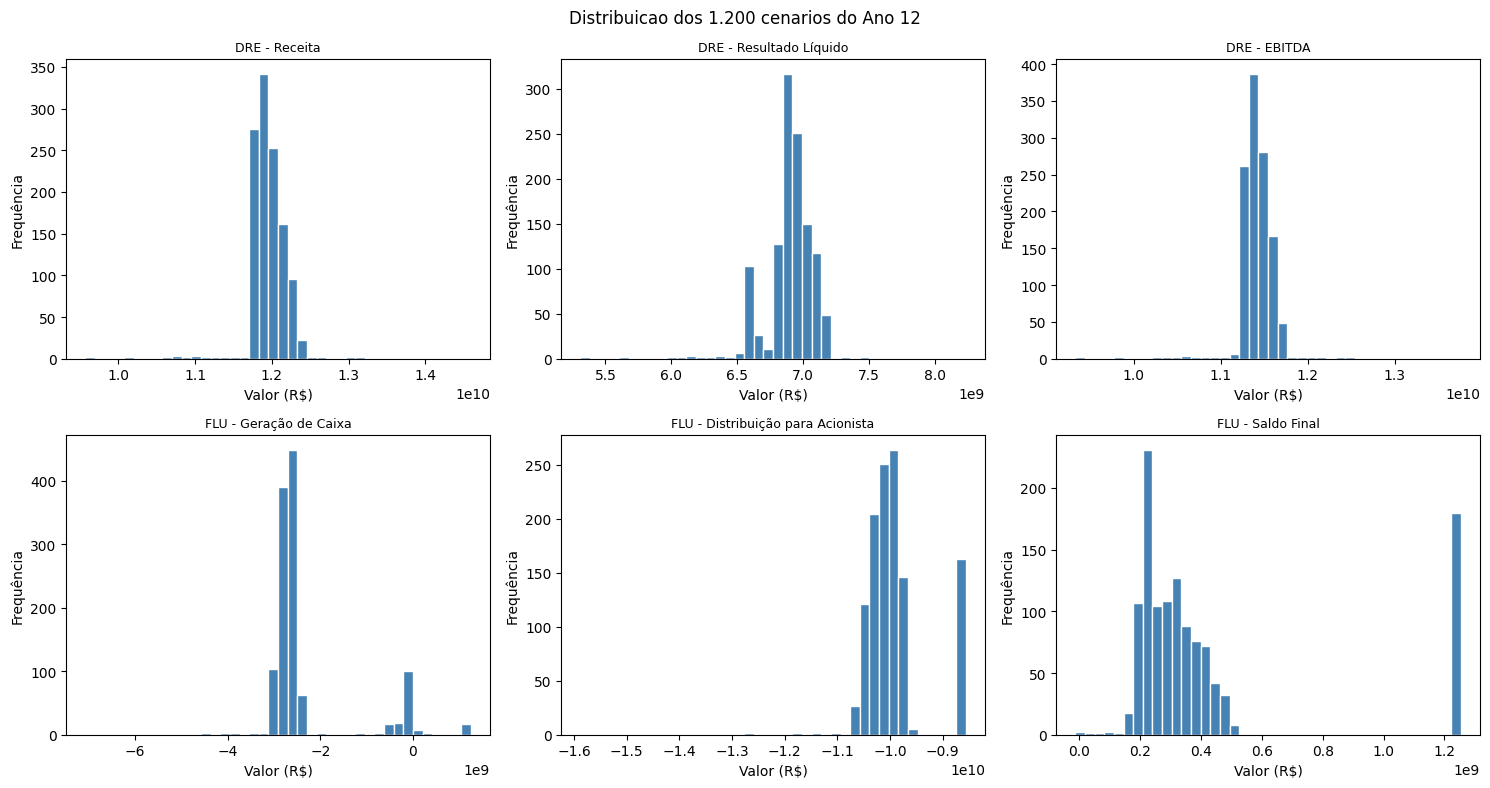

In [ ]:
ano_histograma = 12
dados_ano = pivot.loc[ano_histograma]

fig, eixos = plt.subplots(2, 3, figsize=(15, 8))
for eixo, conta in zip(eixos.flatten(), contas_chave):
    eixo.hist(dados_ano[conta], bins=40, color='steelblue', edgecolor='white')
    eixo.set_title(conta, fontsize=9)
    eixo.set_xlabel('Valor (R$)')
    eixo.set_ylabel('Frequência')

plt.suptitle(f'Distribuicao dos 1.200 cenarios do Ano {ano_histograma}')
plt.tight_layout()
plt.show()

## Passo 9 — Boxplots por ano

O boxplot mostra, para cada ano, a mediana e a distribuição central dos 1.200 cenários. A caixa representa o intervalo entre o primeiro e o terceiro quartil (IQR), enquanto os bigodes representam a extensão dos valores não classificados como atípicos pela regra de 1,5 × IQR. Os pontos classificados como possíveis outliers são analisados separadamente na etapa seguinte.

**O que esperar:** anos com caixas mais altas/compridas têm mais variabilidade entre cenários. Pontos isolados longe da caixa são outliers — cenários que fogem muito do padrão daquele ano.

### 9.1 Boxplot com possíveis outliers

O boxplot apresenta a distribuição dos 1.200 cenários simulados em cada ano. A caixa representa o intervalo entre o primeiro e o terceiro quartil, a linha central representa a mediana e os pontos fora dos limites dos bigodes correspondem a valores classificados como potenciais outliers pela regra de 1,5 × IQR. Esses pontos são mantidos na análise, pois sua classificação estatística não implica necessariamente erro nos dados.

/tmp/ipykernel_913/4205422800.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  eixo.boxplot(
/tmp/ipykernel_913/4205422800.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  eixo.boxplot(
/tmp/ipykernel_913/4205422800.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  eixo.boxplot(
/tmp/ipykernel_913/4205422800.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  eixo.boxplot(
/tmp/ipykernel_913/4205422800.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been 

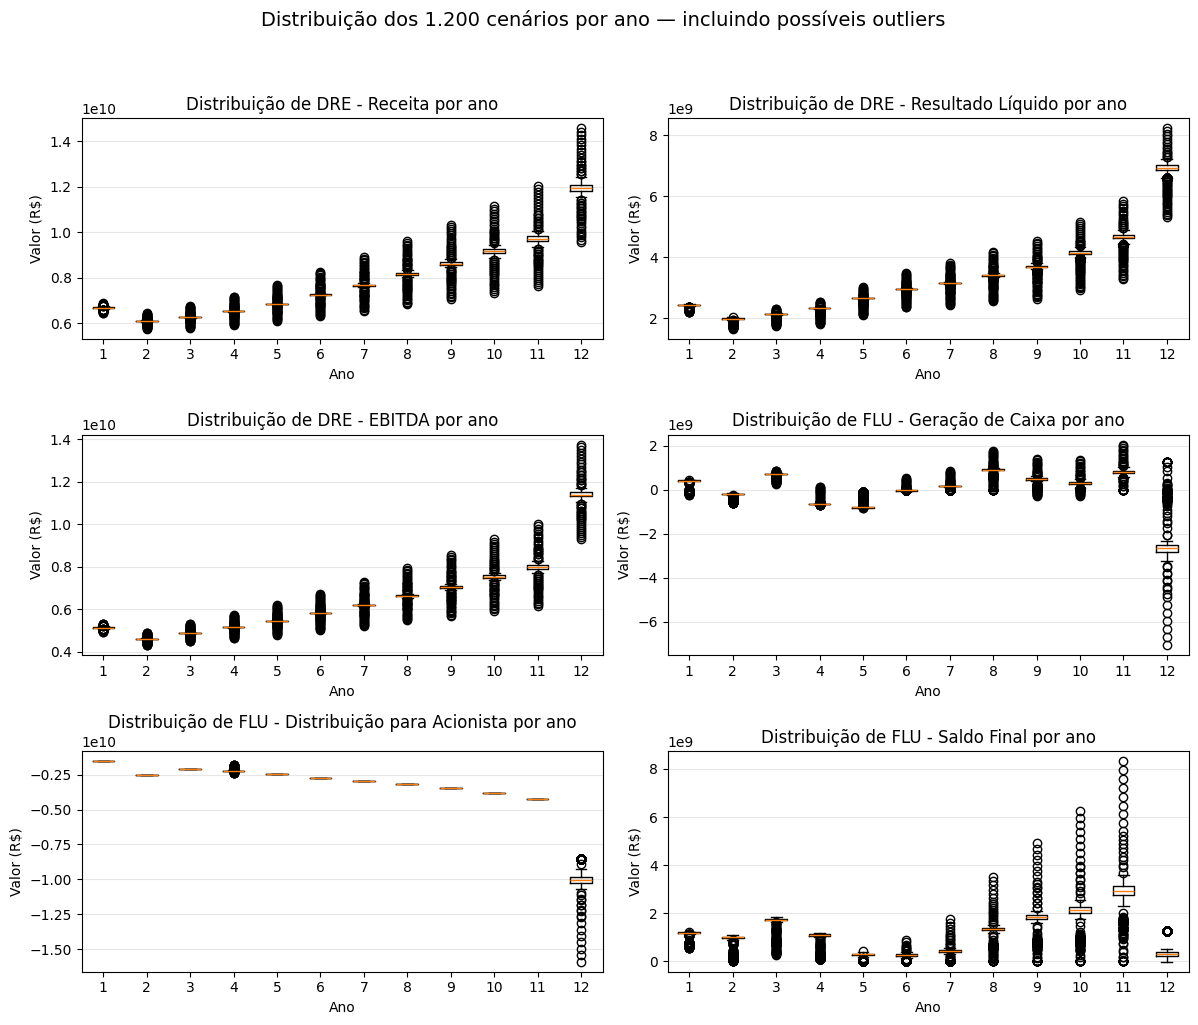

In [ ]:
anos = sorted(pivot.index.get_level_values('AnoNum').unique())

fig, eixos = plt.subplots(3, 2, figsize=(12, 10))

for eixo, conta in zip(eixos.flatten(), contas_chave):

    dados_boxplot = [
        pivot.xs(ano, level='AnoNum')[conta].dropna()
        for ano in anos
    ]

    eixo.boxplot(
        dados_boxplot,
        labels=anos,
        showfliers=True
    )

    eixo.set_title(f'Distribuição de {conta} por ano')
    eixo.set_xlabel('Ano')
    eixo.set_ylabel('Valor (R$)')
    eixo.grid(axis='y', alpha=0.3)

plt.suptitle(
    'Distribuição dos 1.200 cenários por ano — incluindo possíveis outliers',
    fontsize=14,
    y=1.02
)

plt.tight_layout()

plt.savefig(
    'Boxplots por ano - com outliers.png',
    dpi=200,
    bbox_inches='tight'
)

plt.show()

## Passo 9.2 — Boxplot sem exibir os possíveis outliers

Nesta visualização, os possíveis outliers foram ocultados exclusivamente para facilitar a comparação da distribuição central entre os anos.

/tmp/ipykernel_913/3666386653.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  eixo.boxplot(
/tmp/ipykernel_913/3666386653.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  eixo.boxplot(
/tmp/ipykernel_913/3666386653.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  eixo.boxplot(
/tmp/ipykernel_913/3666386653.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  eixo.boxplot(
/tmp/ipykernel_913/3666386653.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been 

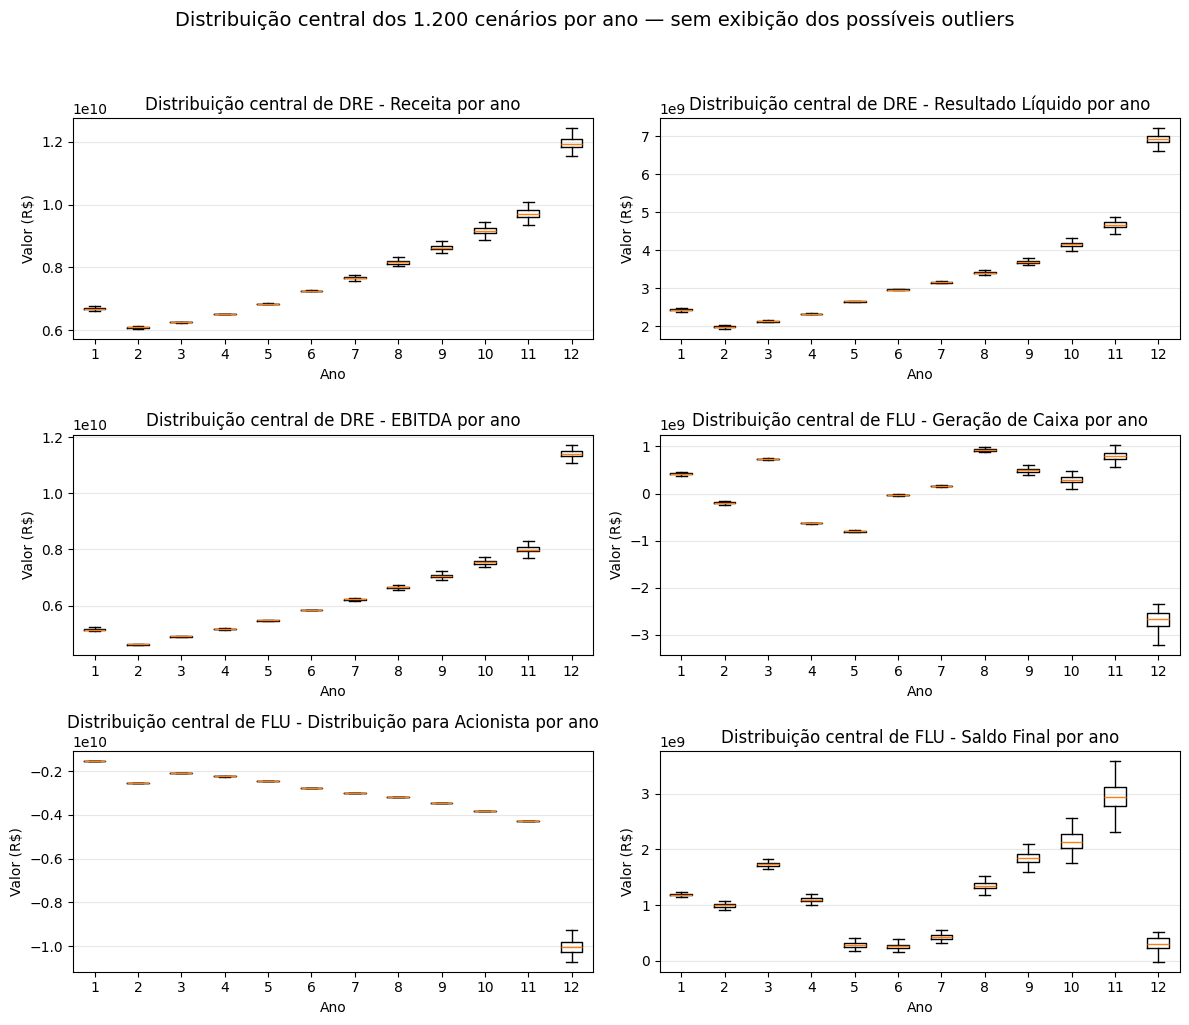

In [ ]:
anos = sorted(pivot.index.get_level_values('AnoNum').unique())

fig, eixos = plt.subplots(3, 2, figsize=(12, 10))

for eixo, conta in zip(eixos.flatten(), contas_chave):

    dados_boxplot = [
        pivot.xs(ano, level='AnoNum')[conta].dropna()
        for ano in anos
    ]

    eixo.boxplot(
        dados_boxplot,
        labels=anos,
        showfliers=False
    )

    eixo.set_title(f'Distribuição central de {conta} por ano')
    eixo.set_xlabel('Ano')
    eixo.set_ylabel('Valor (R$)')
    eixo.grid(axis='y', alpha=0.3)

plt.suptitle(
    'Distribuição central dos 1.200 cenários por ano — sem exibição dos possíveis outliers',
    fontsize=14,
    y=1.02
)

plt.tight_layout()

plt.savefig(
    'Boxplots por ano - sem outliers.png',
    dpi=200,
    bbox_inches='tight'
)

plt.show()

## Passo 10 — Identificação de valores atípicos (outliers)

Usamos a regra estatística padrão do boxplot (regra do IQR): qualquer valor abaixo de `Q1 - 1,5×IQR` ou acima de `Q3 + 1,5×IQR` é considerado atípico, onde IQR é a distância entre o 1º e o 3º quartil.

**O que esperar:** uma tabela com a porcentagem de cenários classificados como outlier, por conta e por ano. Isso não significa erro nos dados — A regra do IQR identifica valores que estão afastados da região central da distribuição. Esses valores não devem ser automaticamente tratados como erros. Como os dados representam cenários simulados, os pontos identificados serão mantidos nesta etapa e analisados de acordo com sua distribuição e frequência. Quando houver concentração significativa de pontos classificados como outliers, isso pode indicar uma distribuição assimétrica ou a presença de diferentes grupos de cenários, e não necessariamente erros nos dados.

In [ ]:
def fracao_outliers(serie):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    return ((serie < limite_inferior) | (serie > limite_superior)).mean()

outliers_por_ano = pivot.groupby('AnoNum').agg(fracao_outliers)
outliers_por_ano

Conta,DRE - Receita,DRE - Resultado Líquido,DRE - EBITDA,FLU - Geração de Caixa,FLU - Distribuição para Acionista,FLU - Saldo Final
AnoNum,,,,,,
1,0.026667,0.145833,0.026667,0.166667,0.000000,0.166667
2,0.041667,0.153333,0.045833,0.163333,0.000000,0.164167
3,0.086667,0.160000,0.062500,0.160000,0.000000,0.163333
4,0.056667,0.162500,0.062500,0.146667,0.161667,0.163333
5,0.063333,0.164167,0.069167,0.164167,0.000000,0.159167
6,0.048333,0.180000,0.167500,0.165833,0.000000,0.160000
7,0.045000,0.202500,0.060833,0.200000,0.000000,0.162500
8,0.043333,0.159167,0.045833,0.163333,0.000000,0.162500
9,0.043333,0.158333,0.043333,0.159167,0.000000,0.161667


## Conclusões desta etapa (para o relatório)

- As 6 contas-chave não têm valores ausentes nem duplicados — a base está íntegra para a análise.
- Geração de Caixa é sistematicamente a conta com maior dispersão relativa (coeficiente de variação) entre as seis, o que já indica onde está concentrada a incerteza do modelo.
- [Completar após rodar: descrever aqui a forma dos histogramas do Passo 8 — simétrica, assimétrica, bimodal — e quais anos concentram mais outliers no Passo 10.]
- Esta análise descritiva é a base para a Entrega 2 (Análise de Regressão), que já está adiantada no notebook de exploração anterior.

## Passo 11 — Exportar as tabelas para o relatório

Junta as tabelas dos Passos 4 a 10 num único `.zip` para vocês usarem na montagem do relatório Word/PDF desta entrega.

In [ ]:
import zipfile
import glob
from google.colab import files

arquivos = (
    glob.glob('e1_*.csv') +
    glob.glob('*.png')
)


arquivos = sorted(set(arquivos))


nome_zip = 'entrega1_resultados.zip'


with zipfile.ZipFile(nome_zip, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for arquivo in arquivos:
        zipf.write(arquivo)

print(f'ZIP criado com sucesso: {nome_zip}')
print('\nArquivos incluídos:')

for arquivo in arquivos:
    print(f' - {arquivo}')

print(f'\nTotal de arquivos: {len(arquivos)}')

files.download(nome_zip)

ZIP criado com sucesso: entrega1_resultados.zip

Arquivos incluídos:
 - Boxplots por ano - com outliers.png
 - Boxplots por ano - sem outliers.png

Total de arquivos: 2


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>